## Lecture 7

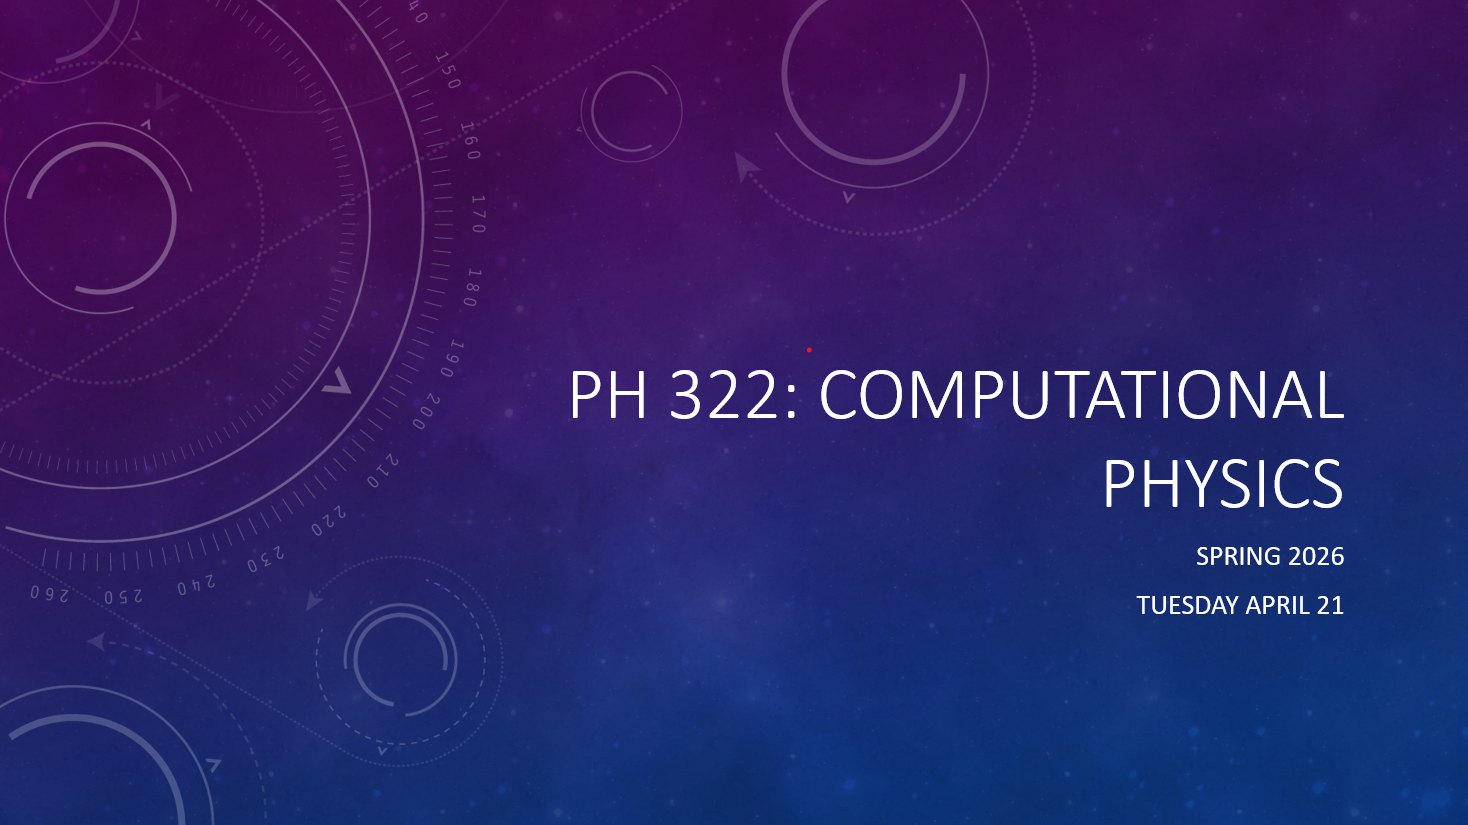

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture7.png"))

HW3 due tonight

### Last class
* Numerical Integration
* Trapezoidal rule
* Simpson's Rule

### Today
* Approximation errors using the trapezoid and Simpson's rules
    * Euler-Maclaurin formula for functions that can be differentiated
    * 2nd method for functions that can't be differentiated
* Gaussian Quadrature





### Review trapezoidal and Simpson's rules

The trapezoidal and Simpson's rules are numerical methods to approximate a definite integral. In both we divide the area under the function to integrate into $N$ slices and estimate the area of each slice. For the trapezoid method we approximate the shape of each slice as a trapezoid, and for Simpson's method we fit the function over each pair of slices with a quadratic and calculate the area underneath the fit. 

**Trapezoidal Rule**
$$
I(a,b) = \int_a^b f(x)dx \sim h\left[\frac{1}{2}f(a)+\frac{1}{2}f(b)  +  \sum_{k=1}^{N-1} f(a+kh) \right]
$$      

**Simpson's Rule**
$$
I_{a,b} = \int_a^b f(x)dx \sim \frac{1}{3}h\left[f(a) + f(b) + 2\sum_{k=2, \text{even k}}^{N-2} f(a+kh) + 4\sum_{k=1, \text{odd k}}^{N-1} f(a+kh)\right]
$$ 

### Practice Exercise: Compare Simpson's rule against the trapezoidal rule

1. For a range of $N$, estimate the same integral using both Simpson's rule and the trapezoidal rule. If you did the above exercises, you should be able to recycle most of what you need for this exercise.
2. Plot the relative error of the estimate vs. $N$ for both the Simpson's rule and the trapezoidal rule on the same plot.
3. What value of $N$ do the estimates converge?
4. Try experimenting with different functions to integrate. 




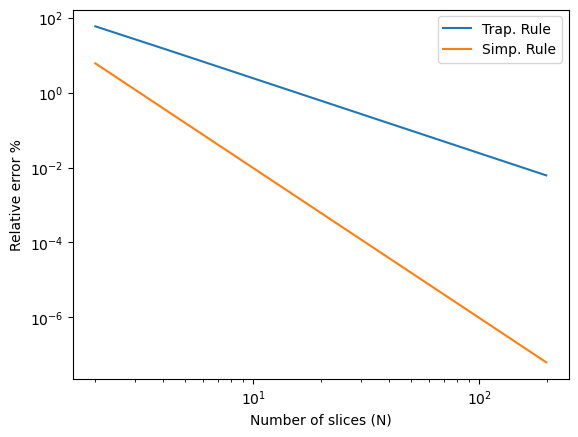

In [1]:
# PROGRAM - Compare the Trapezoidal Rule and Simpson's Rule



### Comparision of approximation error using TR and SR
|N|TR|SR|
|:-|:-:|-:|
|10|2.4%|0.0097%|
|100|0.02%|9.7e-7%|
|1000|0.0002%|9.7e-11%|
|1e6|2.45e-10%|9.9e-13%|

You can see the significant improvement we get in accuracy when using Simpson's rule. Even with only 10 slices, we achieve an accuracy of about 0.01%. We are getting close to reaching the limits of numerical precision already with $N=1000$ slices. 

We see that Simpson's rules gives us a lot of bang for our buck. High accuracy is achieved with a fairly simple computational algorithm that doesn't require much code writing. 

## Integration approximation errors

Any estimate of an integral calculated by numerical methods will have some amount of approximation error, since we are not calculating the exact area under the function.

In the cases above, we've been able to calculate what this approximation error is, because we were able to calculate the exact integral by evaluating the integral analytically. 

However, the main purpose of using numerical methods is to calculate integrals we can't evaluate analytically, so in most cases we don't know what the exact integral is, so we can't directly calculate the approximation error.

But we would like to know something about how accurate our numerical estimate is. Not only will that be needed to specifiy uncertainty on our integral, but it will also inform our decision about how large we should make $N$.

Remember, there is always a trade-off in our choice of $N$, the number of slices we break the integration range into. Small $N'$s produce fast calculations, but higher approximation error. Large $N'$s produce smaller approximation errors and more accurate estimates but they take longer to compute. 

This choice may not matter if we are calculating 1 or 2 integrals, but the calculation time can quickly increase if we are dealing with more than a handful of integrations. 

This section will teach us how to estimate what the approximation error of our integral is, even without knowing what the exact integral is. 

**Review Taylor series**

To do this, we will perform a Taylor series expansion of the function we wish to integrate, i.e. the *integrand*, about some points in our integration interval. This will help us see what we're missing when we use either the trapezoidal rule or Simpson's rule to integrate.

Review what a [Taylor's series](https://en.wikipedia.org/wiki/Taylor_series) is (from wikipedia):

*The Taylor series of a function is an infinite sum of terms that are expressed in terms of the function's derivatives at a single point. For most common functions, the function and the sum of its Taylor series terms are equal near this point. The Taylor series is named after Brook Taylor who introduced them in 1715.*

The Taylor series of a function *f(x)* that is infinitely differentiable at $x=a$ is:

$$
f(x) = \sum_{n=0}^{\infty}\frac{f^{(n)}(a)}{n!}(x-a)^n
$$

or:

$$
f(x) = f(a)+\frac{f'(a)}{1!}(x-a) + \frac{f''(a)}{2!}(x-a)^2+\frac{f'''(a)}{3!}(x-a)^3+ ...
$$

We see that we can improve the approximation to the function by keeping higher order terms in the series.

Let's derive the Taylor series terms for the function we've been working with:

$ 
f(x) = x^4 -2x +1  
$

Calculate all its derivatives:

$
f'(x) = 4x^3 -2  
$ 

$
f''(x) = 12x^2  
$

$
f'''(x) = 24x  
$

$
f''''(x) = 24  
$

Now approximate $f(x)$ about x=1 using an increasing number of terms in the Taylor series expansion. 

Plot each approximation against the true function.  

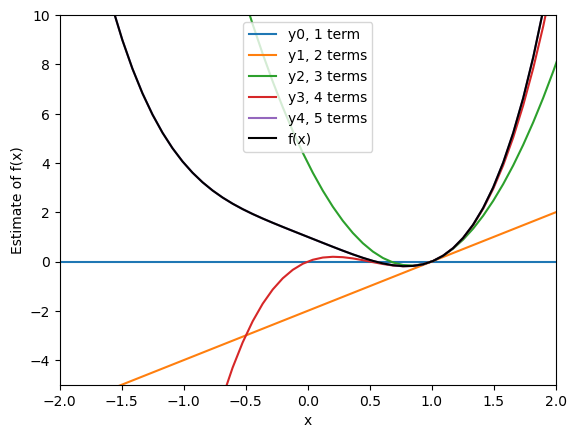

In [3]:
import math as m
import numpy as np
import matplotlib.pyplot as plt

# create functions to calculate all the derivatives of f(x)
def f(x):
    return x**4-2*x+1

def f1(x):
    return 4*x**3-2

def f2(x):
    return 12*x**2

def f3(x):
    return 24*x

def f4(x):
    return 24

# main program
llim = -4
ulim = 4
N = 100

# create array to hold the x-values
x = np.linspace(llim,ulim,N)

# we will evaulate the function at x=1
a = 1

# approximate the function using an increasing number of Taylor series terms

# f(x) approximated with 1 term
y0 = np.full(N, f(a))
# f(x) approximated with 2 terms
y1 = f(a) + f1(a)*(x-a)
# f(x) approximated with 3 terms
y2 = f(a) + f1(a)*(x-a) + f2(a)*np.power(x-a,2)/2.0
# f(x) approximated with 4 terms
y3 = f(a) + f1(a)*(x-a) + f2(a)*np.power(x-a,2)/2.0 \
        + f3(a)*np.power(x-a,3)/6
# f(x) approximated with 5 terms
y4 = f(a) + f1(a)*(x-a) + f2(a)*np.power(x-a,2)/2.0 \
        + f3(a)*np.power(x-a,3)/6 + f4(a)*np.power(x-a,4)/24
# the true f(x) 
y = f(x)

# plot all approximations against the true function
plt.plot(x,y0, label="y0, 1 term")
plt.plot(x,y1, label="y1, 2 terms")
plt.plot(x,y2, label="y2, 3 terms")
plt.plot(x,y3, label="y3, 4 terms")
plt.plot(x,y4, label="y4, 5 terms")
plt.plot(x,y, 'k', label="f(x)")
plt.xlabel("x")
plt.ylabel("Estimate of f(x)")
plt.legend()
plt.ylim(-5,10)
plt.xlim(-2,2)
plt.show()


We see that near $a,  (x=1)$, we approximate $f(x)$ better and better, as we add more terms to the approximation. Finally when we add all terms, y4, we reproduce $f(x$) exactly.

The order of the error in each approximation is determined by the terms not included in the approximation.

For example, in $y1$ we neglected terms proportional to  $(x-a)^2$ and higher. So the error on y1, i.e., the approximation error, is proportional to $(x-a)^2$. We say $y1$ 
is a first-order approximation, accurate to terms proportional to $O(x-a)$, and has an error $O((x-a)^2)$. 

Likewise $y3$ is a second-order approximation accurate to terms proportional to $O((x-a)^2)$, and has an error $O((x-a)^3)$.  



With this background of the Taylor series in place, we can better understand how we will estimate the approximation error for integrals.

Basically what we're going to do is this:

* Write the integral as a Taylor series. Compare this with the trapezoid and Simpson's rules. The terms of the Taylor series not included in either rule is the approximation error since these are the terms we don't calculate.

To write the integral as a Taylor series we do these steps:
1. Divide the interval into $N$ slices.
2. Write the integrand as a Taylor series at the endpoints of a given slice.
3. Integrate the Taylor series over the slice (this is the area of the slice).
4. Sum up over all slices.
5. Simplify the result.
6. Compare the result with the trapezoid and Simpsons rules.

After we do this, we will see that both the trapezoidal rule and Simpson's rules are *truncated Taylor series of the integral* we are evaluating. This will allow us to see what terms we are neglecting when use these rules. 

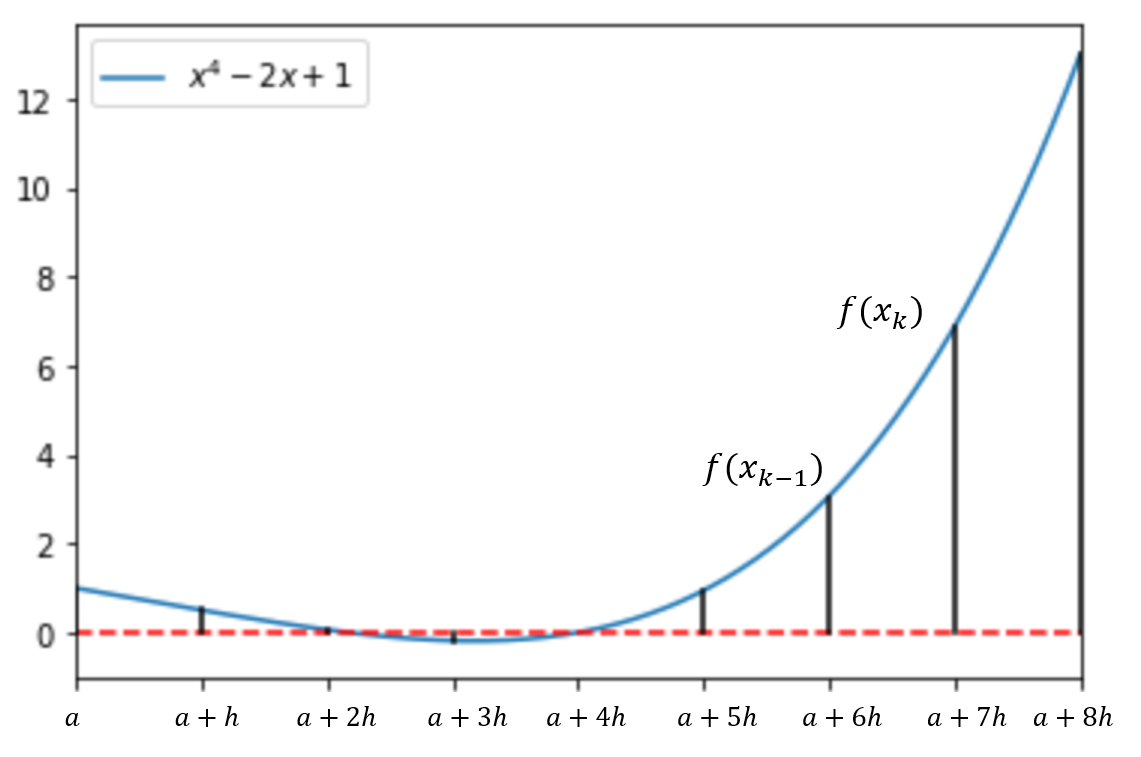

To make the notation less cumbersome, we relabel the slice boundaries $x_k$, where $k=0,...,N$, and $x_k=a+kh$. 

For example:

$x_0=a$, $x_1=a+h$, and $x_N=b$.

First we write the Taylor's series of $f(x)$ about the sample point $x_{k-1}$. (Here I am drawing $x_{k-1}$ at  $x=a+6h$ and $x_k$ at $x=a+7h$, but they could be drawn for the sample points bordering any slice.)

$
f(x) = f(x_{k-1})+f'(x_{k-1})(x-x_{k-1})+\frac{1}{2}f''(x_{k-1})(x-x_{k-1})^2 + ...
$

If we were to include all terms of the series, this would be exactly $f(x)$.

We now integrate this expression exactly over the slice from $x_{k-1}$ to $x_{k}$. This will be the true area of the slice if we retain all terms in the series:

$$
A_k = \int_{x_{k-1}}^{x_k} \left(f(x_{k-1})+f'(x_{k-1})(x-x_{k-1})+\frac{1}{2}f''(x_{k-1})(x-x_{k-1})^2 + ...\right) dx
$$

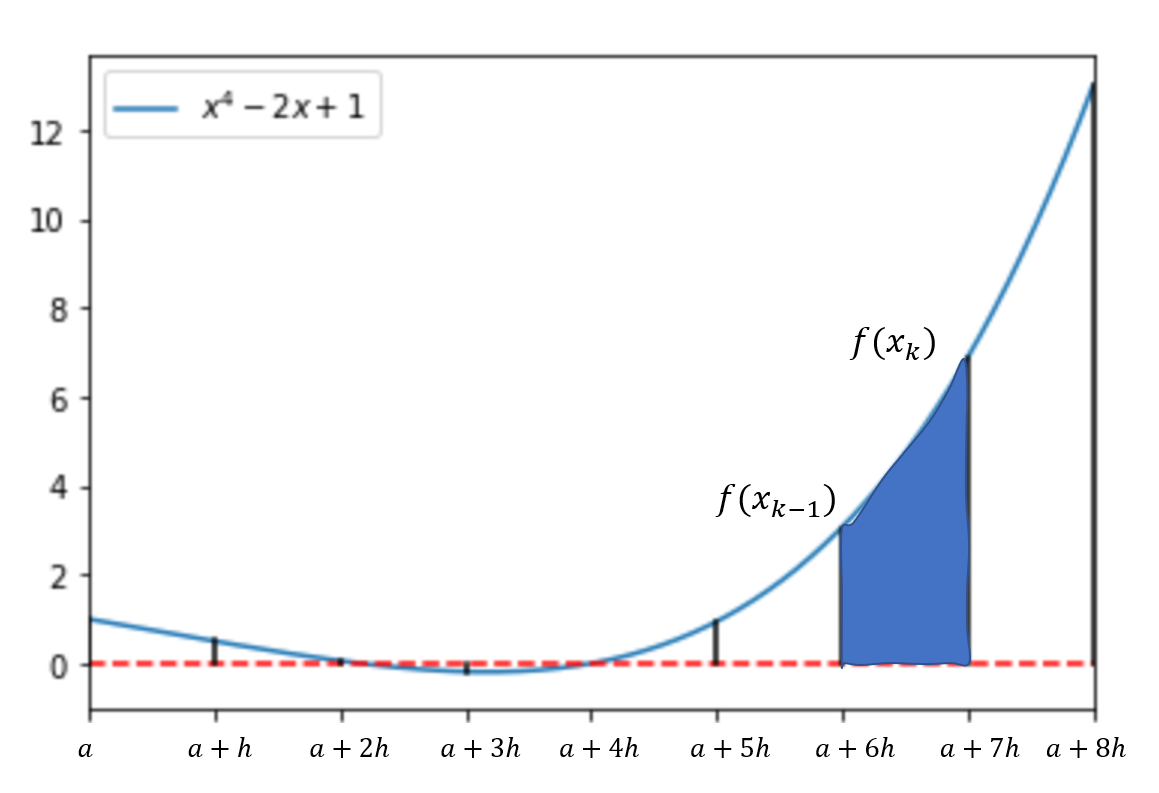

Using a change in variables ($u=x-x_{k-1}$), and substituting $h=x_k-x_{k-1}$, the integral can be evaluated to :

$$
A_k = hf(x_{k-1})+\frac{1}{2}h^2f'(x_{k-1})+\frac{1}{6}h^3f''(x_{k-1}) + O(h^4),
$$

where $O(h^4)$ includes all terms of power $h^4$ and higher. 

We repeat this exercise to calculate the area of the same slice using the Taylor series of $f(x)$ around sampling point $x_k$:

$
f(x) = f(x_{k})+f'(x_{k})(x-x_{k})+\frac{1}{2}f''(x_{k})(x-x_{k})^2 + ...
$

Again we integrate $f(x)$ over slice $k$:

$$
A_k =  \int_{x_{k-1}}^{x_k} \left(f(x_{k})+f'(x_{k})(x-x_{k})+\frac{1}{2}f''(x_{k})(x-x_{k})^2 + ...\right) dx
$$

and we get:

$$
A_k = hf(x_{k})-\frac{1}{2}h^2f'(x_{k})+\frac{1}{6}h^3f''(x_{k}) - O(h^4)
$$

We now have two different expressions for the area of slice $k$. 

If we average the two, we get:

$$
A_k = \frac{1}{2}h\left[f(x_{k-1}) + f(x_k)\right] + \frac{1}{4}h^2\left[f'(x_{k-1})-f'(x_k)\right] + \frac{1}{12}h^3\left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

Let's keep in mind what this is. 

This is the true area of slice $k$ written out in terms of the Taylor series of $f(x)$ at the boundaries of the slice, $x_{k-1}$ and $x_k$.

If we want the entire integral of $f(x)$ from $a$ to $b$, 

$$
I_{a,b}=\int_{a}^b f(x)dx, 
$$

we sum all the $A_k$'s from $a$ to $b$. This turns out to be:


$$= \frac{1}{2}h\sum_{k=1}^N \left[f(x_{k-1}) + f(x_k)\right] + \frac{1}{4}h^2\left[f'(a)-f'(b)\right] + \frac{1}{12}h^3 \sum_{k=1}^N \left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

OK, so why have we done this?

Well, take a closer look at the first term:

$$
\frac{1}{2}h\sum_{k=1}^N \left[f(x_{k-1}) + f(x_k)\right]
$$

Let's evaluate this for $N=3$, over the range $a$ to $b$:

$$
=\frac{1}{2}h\left(f(x_0)+f(x_1)+f(x_1)+f(x_2)+f(x_2)+f(x_3)\right)
$$

$$
= \frac{1}{2}h\left(f(a) +2f(x_1)+2f(x_2)+f(b)\right),
$$
since $a=x_0$, and $b=x_3$. If we rearrange and write the middle terms using a summation we get:

$$
=h\left(\frac{f(a)+f(b)}{2}+ \sum_{k=1}^{N-1}f(x_k)\right)
$$

where $x_k=a+kh$, so we could also write this:

$$
=h\left(\frac{f(a)+f(b)}{2}+ \sum_{k=1}^{N-1}f(a+kh)\right)
$$

Does this look familiar?


This is just the trapezoidal rule. Recognizing this, we can rewrite the total integral above as:

$$
I_{a,b}=\int_{a}^b f(x)dx = \text{trapezoidal rule} + \frac{1}{4}h^2\left[f'(a)-f'(b)\right] + \sum_{k=1}^N \frac{1}{12}h^3\left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

What does this tell us? 

The first term on the RHS is the part of the integral we calculate using the trapezoidal rule. All of the other terms are the terms we ignore or throw out. In other words, the missing terms are the approximation error of the integral we estimate using the trapezoidal rule.

So we could write:

$$
I_{a,b}=\int_{a}^b f(x)dx = \text{trapezoidal rule} + \text{approximation error}
$$ 

where 

$$
\text{approximation error} = \frac{1}{4}h^2\left[f'(a)-f'(b)\right] + \frac{1}{12}h^3\sum_{k=1}^N \left[f''(x_{k-1})+f''(x_k)\right] + O(h^4)
$$

We could stop here, and calculate the approximation error of the trapezoidal from the first two terms above. But this would require calculating both the first and second derivatives of the function and do the summation in the second term. We can simplify this a bit with some mathematical trickery.

Notice the second term in the approximation error, the term with $h^3$, it looks suspiciously close to the trapezoidal rule approximation to the integral of $f''$ (compare with the version of the trapezoidal rule written as: $\frac{1}{2}h\sum_{k=1}^N \left[f(x_{k-1}) + f(x_k)\right]$]).  

 
To see this, let's say we used the trapezoidal rule to evaluate the integral of $f''(x)$ from $a$ to $b$:

$$
\int_a^b f''(x) dx = \frac{1}{2}h\sum_{k=1}^{N}\left[f''(x_{k-1}) - f''(x_k)\right] + O(h^2)
$$

where $O(h^2)$ represents all the terms proportional to $h^2$ we ignore.



Now multiple both sides by $\frac{h^2}{6}$ and rearrange:

$$
\frac{1}{12}h^3\sum_{k=1}^{N}\left[f''(x_{k-1}) - f''(x_k)\right] = \frac{h^2}{6}\int_a^b f''(x) dx -  O(h^4)
$$

$O(h^2)$ becomes $O(h^4)$ because we multiply $O(h^2)$  by $h^2$.

The integral of $f''$  evaluates to: 

$$
\int_a^b f''(x) dx =f'(b)-f'(a).  
$$

Substituting this into the right-hand side:
$$
\rightarrow \frac{1}{12}h^3\sum_{k=1}^{N}\left[f''(x_{k-1}) - f''(x_k)\right] = \frac{h^2}{6}(f'(b)-f'(a)) -  O(h^4)
$$




We now substitute this expression back into our equation for the approximation error. Doing so we get:
$$
\begin{align*}
    \text{approximation error} & =\frac{1}{4}h^2\left(f'(a)-f'(b)\right) + \frac{h^2}{6}(f'(b)-f'(a)) + O(h^4) \\
     & =h^2\left(\frac{1}{4}f'(a) -\frac{1}{4}f'(b) + \frac{1}{6}f'(b)-\frac{1}{6}f'(a)\right) + O(h^4)\\
     & =\frac{h^2}{12}\left(3f'(a)-3f'(b)+2f'(b)-2f'(a)\right) + O(h^4) \\
     & =\frac{h^2}{12}\left(f'(a)-f'(b)\right) + O(h^4)
\end{align*}
$$



What are we looking at?

This is now a simple equation we can use to calculate the approximation error when we use the trapezoidal rule to estimate an integral. 

Because $h$ will almost always be less than 1, the first term will almost always be larger than the remaining terms so we use the first term as the approximation error:

$$
\frac{h^2}{12}\left(f'(a)-f'(b)\right),
$$

is called the **Euler-Maclaurin formula for the error on the trapezoidal rule**. 

So we can write the approximation error on our estimate of the integral using the trapezoidal rule as:

$$
\boxed{\epsilon = \frac{h^2}{12}\left(f'(a)-f'(b)\right)} 
$$ 

If we can analytically differentiate the function $f(x)$ we're integrating, we can easily calculate $f'(a)$ and $f'(b)$. Since we also know the slice width $h$, we can calculate the  trapezoidal rule approximation error. 

This tells us the trapezodial rule is accurate up to terms proportional to $h$ and its error is proportional to $h^2$. Because of this, we call the trapezoidal rule a **first-order integration method**. 



**Approximation error using Simpson's Rule**

We can go through a similar derivation to determine the approximation error on our estimate when we use Simpson's Rule. It turns out to be:

$$
\boxed{\epsilon = \frac{1}{180}h^4\left(f'''(a) - f'''(b)\right)}
$$

This tells us that the error when using Simpson's Rule is proportional to $h^4$ meaning that the approximation we get of the integral using Simpson's Rule is accurate to order $h^3$. Simpson's Rule is a **third-order integration method**. This explains why we get a better estimate of the integral using SR over TR for the same number of slices.

***Note:*** There is an error in the first edition of the textbook. The ratio in equation 5.24 should be $\frac{1}{180}$ not $\frac{1}{90}$. 

### Practice Exercise - Approximation error using the Euler-Maclaurin formula

Use the *Euler-Maclaurin formula* to estimate the approximation error on an integral we estimate with the trapezoidal rule for $N=1$ to $N=1000$

Again use this integral:

$$
I= \int_0^2 (x^4 -2x +1) dx
$$

Make a plot of the error vs. $N$.



First find $f'(x)$:

$$
f'(x) = 4x^3 - 2
$$

Then:

$$
f'(a)=f'(0) = -2
$$

$$
f'(b)=f'(2)=30
$$

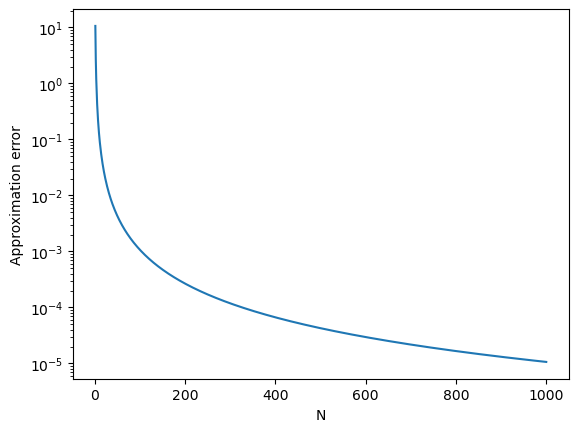

In [42]:
# Practice Exercise - Approximation error using the Euler-Maclaurin formula


We see the error goes down as $N$ increases. Can we indefinitely decrease the error by increasing $N$? 

Well no. 

At some point the approximation error becomes less than the rounding error. There is no point increasing $N$ past this point. 

So what is the largest $N$ we should use?

It's when the approximation error equals the numerical error $C$. Remember we defined the numerical error on a floating point number $x$ as $xC$, where $C=10^{-16}$. In the current case the float $x$ is the integral $I$ we're estimating.

So the largest N is determined by when the trapezoidal approximation error equals the rounding error on the integral we estimate with the TR:

$$
\text{approximation error} = \text{rounding error}
$$

$$
\frac{h^2}{12}\left(f'(a) - f'(b)\right) = C\int_{a}^{b}f(x)dx
$$

Solve for $h$:

$$
h=\sqrt{\frac{12\int_a^b f(x)dx}{f'(a)-f'(b)}}C^{1/2}
$$

And since $h=\frac{b-a}{N}$:

$$
\frac{b-a}{N}=\sqrt{\frac{12\int_a^b f(x)dx}{f'(a)-f'(b)}}C^{1/2}
$$

and finally, solve for $N$:

$$
N = (b-a){\sqrt{\frac{f'(a)-f'(b)}{12\int_a^b f(x)dx}}C^{-1/2}}
$$


Plug in numbers:

a=0  
b=2  
$f'(a) = -2$

$f'(b) = 30$

$
12\int_a^b f(x)dx = 52.8
$

$C^{-1/2} \sim 10^8
$

So $N\sim 10^8$, and for larger $N$'s,the rounding error will dominate.

Generally we see there is no point using more than $10^8$ slices with the trapezoidal rule. Beyond that, the uncertainty in the estimate of the integral comes from numerical rounding error not approximation error.

We can go through a similar exercise using Simpson's rule and find we reach the rounding error at only $N=10^4$, which again shows how much more accurate the Simpson's rule is. 



### How do you calculate errors on integrals if you can't compute its derivatives?


We found that if we can calculate the derivatives of our function we can calculate the error on our estimate of the integral using the trapezoidal rule (TR) and Simpson's rule (SR):

**Approximation error on I using TR**  

$$
\epsilon = \frac{h^2}{12}\left(f'(a)-f'(b)\right)
$$

**Approximation error on I using SR**  

$$
\epsilon = \frac{h^4}{180}\left(f'''(a)-f'''(b)\right)
$$



These work great if you know the derivatives of the function. But this is not always the case, especially in the case where we are integrating numerical data. In these cases, we need an alternative method to estimate the approximation error. 

Let me cut to the solution. 

Calculate the integral with $N$ slices, call this integral $I_1$, then calculate the integral again, but this time with  $2N$ slices, call this integral $I_2$. The difference between $I_2$ and $I_1$ is the approximation error of $I_2$. 

How?



Let's again take a look at the Taylor's series expansion of the integral in terms of the trapezoidal rule:

$$
I_{a,b}=\int_a^b f(x)dx = \underbrace{\frac{h}{2}\sum_{k=1}^N\left[f(x_{k-1})+f(x_k)\right]}_{\text{trapezoidal rule}} + \underbrace{\frac{h^2}{12}\left(f'(a)-f'(b)\right)}_{\text{approximation error}} + O(h^4)
$$

The approximation error is proportional to $h^2$ so we can write the approximation error as $ch^2$, where $c$ is some constant.

Let's say we use $N_1$ slices to estimate the integral using the TR. Call this estimate $I_1$. 

Therefore the true integral $I_{a,b}$ can be written:

$$
I_{a,b} = I_1 +ch_1^2,
$$  

where $h_1= \frac{b-a}{N_1}, $ the slice width using $N_1$.



Now let's estimate the integral again but this time with twice the number of slices $N_2=2N_1$. Call this estimate $I_2$:

$$
I_{a,b} = I_2 +ch_2^2.
$$, 



Since these are both exact solutions for the integral, they must be equal:

$$
I_1 +ch_1^2 = I_2 +ch_2^2,
$$

and rearranging:

$$
I_2-I_1 = ch_1^2 - ch_2^2.
$$



But we know:

$$
h_1 = 2h_2,
$$ 

because $N_2=2N_1$, so:

$$
I_2-I_1 = 4ch_2^2 - ch_2^2 = 3ch_2^2.
$$


Rearranging:

$$
ch_2^2 = \frac{1}{3}(I_2-I_1)
$$

But .. 

$ch_2^2$ *is* the error term for our estimate of $I_2$ (where we used $N_2$ slices). 

So we can write:

$$
\boxed{\epsilon_2 = ch_2^2 = \frac{1}{3}(I_2-I_1)} \:\:\:\text{\bf{approximation error using the trapezoidal rule}} 
$$ 



So .. this is good. 

We can easily estimate the approximation error by applying the trapezoidal rule twice, once using $N$ slices, then again using $2N$, then calculate $\epsilon$ with the equation above.  

There is a similar expression that gives the approximation error when we estimate integrals using the Simpson's rule:

$$
\boxed{\epsilon_2 = ch_2^2 = \frac{1}{15}(I_2-I_1)}  \:\:\:\text{\bf{approximation error using Simpson's rule}} 
$$ 

Note the only difference is the prefactor ratio. 

### Practice exercise: Estimate approximation error using the doubling method

Use the trapezoidal rule to estimate the integral:

$$
I = \int_{0}^{2} (2x^5-x^4+x)dx
$$

Estimate the approximation error of the estimate for $N=10$ using the doubling method. Also compute the error using the Euler-Maclaurin formula and compare. 

In [32]:
# Practice exercise: Estimate approximation error using the doubling method
 


Error estimated using the doubling N technique = 0.0100. 
Error estimated using the Euler-MacLaurin formula = 0.0013. 


We see that the errors are in good agreement. 


## Gaussian quadrature 

Let's review.

The trapezoidal rule is a first-order integration method. We derived it by fitting the integrand with a straight line over each integration slice.

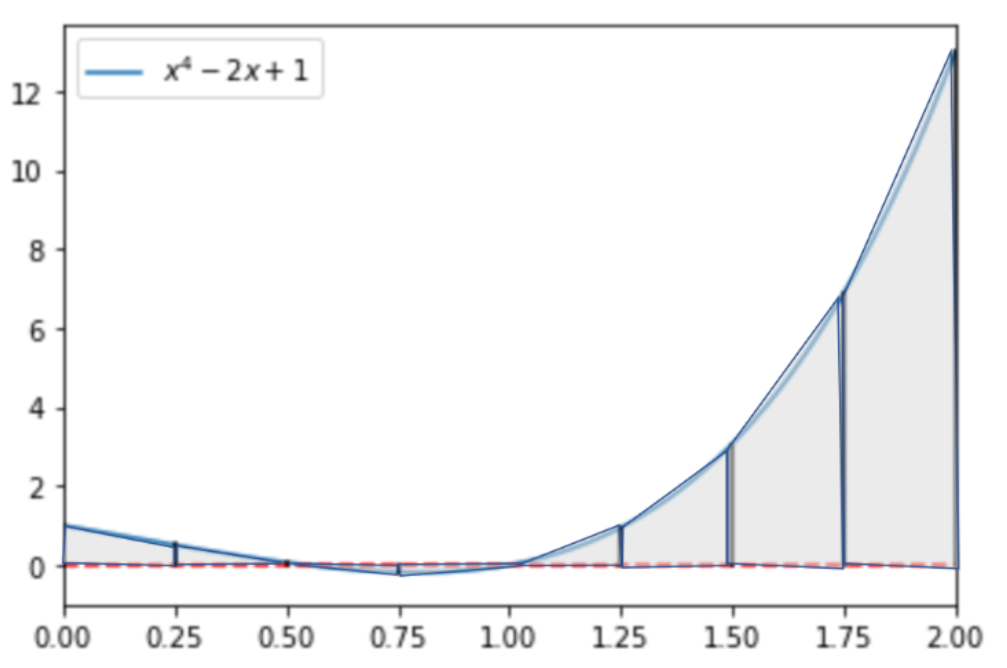


Simpson's rule is a third-order integration rule. We derived it by fitting the integrand wtih a quadratic, which is a second-order polynomial over each integration slice. 


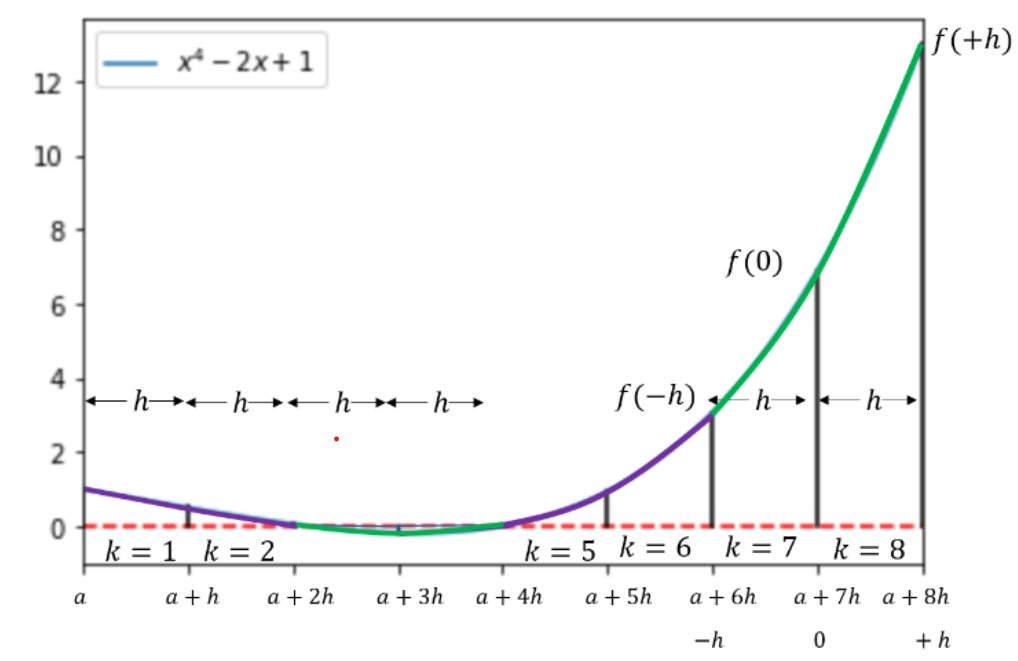


Let's compare the two

**Trapezoidal Rule** 

$$
I_{a,b} = h\left[\frac{1}{2}f(a)+\frac{1}{2}f(b)  +  \sum_{k=1}^{N-1} f(a+kh) \right]
$$ 

**Simpson's Rule**  
$$
I_{a,b} = \frac{1}{3}h\left[f(a) + f(b) + 2\sum_{k=2, \text{even k}}^{N-2} f(a+kh) + 4\sum_{k=1, \text{odd k}}^{N-1} f(a+kh)\right]
$$


Notice that every term in both rules is the integrand $f(x)$ evaluated at a sample point, multiplied by some pre-factor. For example the first term of the trapezoidal rule is the integrand evaluated at sample point $a$ multiplied by $\frac{h}{2}$, while the pre-factor is just h for every term in the sum.

Likewise the pre-factor on the first term in Simpson's Rule is $\frac{h}{3}$, while the pre-factors on the odd and even slices are $\frac{2h}{3}$ and $\frac{4h}{3}$, respectively.

In general we can write both rules in this form:

$$
\int_a^b f(x) dx \approx \sum_{k=1}^{N} w_{k}f(x_k)
$$

where $x_k$ are the sample points, and $w_k$ is the pre-factor or the *weight* multiplying the $k$th term.

In general, **we approximate the integral by sampling the integrand at a number of sampling points, and multiplying each sample by an appropriate weight.**

We can see how this weighting system works by plotting the weights, i.e. the coefficients, at the sample points, for each rule.

We'll start first with the trapezoidal rule:


sum of weights=  20.0


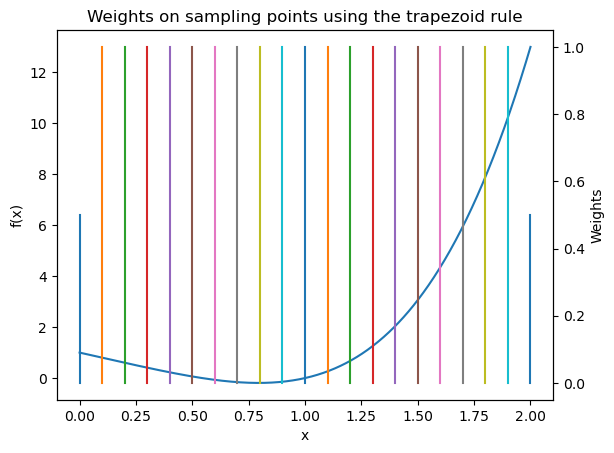

In [4]:
# Plot sampling points and weights of trapezoidal rule

import numpy as np
import matplotlib.pyplot as plt

# define the function in the integrand
def f(x):
    return x**4-2*x+1

# set the limits of integration
a=0
b=2
# set N
N=20

h = (b-a)/N

# populate arrays with x and y values of function
xvalues = np.linspace(a, b, 1000)
yvalues = f(xvalues)

# get the axes object so we can define a 2nd y-axis
ax1 = plt.gca()
ax1.plot (xvalues, yvalues)

# next define the sampling points and store in array
xp = np.arange(a,b+h,h)
# create an array of same size to hold the weights and initialize to 1
wp = np.full([len(xp)], 1.0)

# specify weights at endpoints
wp[0]=1/2
wp[N]=1/2
 
# create a second y-axis
ax2 = ax1.twinx()
print ("sum of weights= ", sum(wp))

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')
    
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax2.set_ylabel("Weights")
plt.title("Weights on sampling points using the trapezoid rule")
plt.show()

Notice that all the weights are equal to 1 except at end points.  Also, all sampling points are equally spaced.

Let's repeat but now for Simpson's Rule:

sum of weights=  19.999999999999996


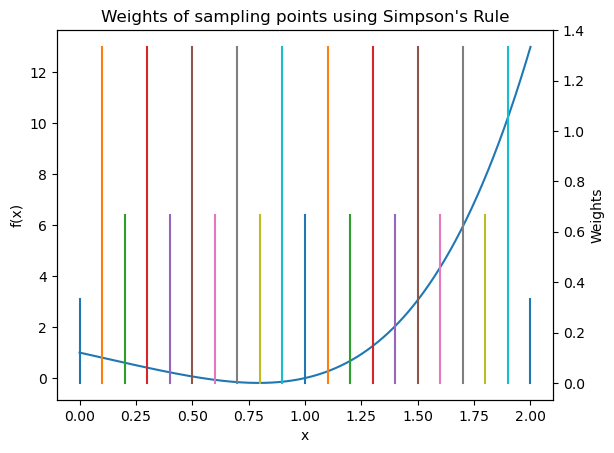

In [5]:
# Plot sampling points and weights of Simpson's rule

import numpy as np
import matplotlib.pyplot as plt

# define the function in the integrand
def f(x):
    return x**4-2*x+1

# set the limits of integration
a=0
b=2
# set N
N=20

h = (b-a)/N

# populate arrays with x and y values of function
xvalues = np.linspace(a, b, 1000)
yvalues = f(xvalues)

# get the axes object so we can define a 2nd y-axix
ax1 = plt.gca()
ax1.plot (xvalues, yvalues)

# define sampling points
xp = np.arange(a,b+h,h)
# create array of equal size to store weights and initialize to 1/3
wp = np.full([len(xp)], 1/3)

# change weights of even and odd terms
for k in range(1,N):
    if k%2 == 0:
        wp[k]=2/3
    if k%2 == 1:
        wp[k]=4/3
        
# create a second y-axis
ax2 = ax1.twinx()
print ("sum of weights= ", sum(wp))

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')
    
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax2.set_ylabel("Weights")
plt.title("Weights of sampling points using Simpson's Rule")
plt.show()

Again, the weights are smallest at the endpoints, but here the weights alternate between even and odd values of $k$ for $x_k$.

We see that our integration rules are really just different sets of weights to the function when we evaluate it at the location of our sampling points.

Notice that if our integrand is a straight line, then the trapezoidal rule would provide an exact estimate of the integral.

sum of weights=  1.0


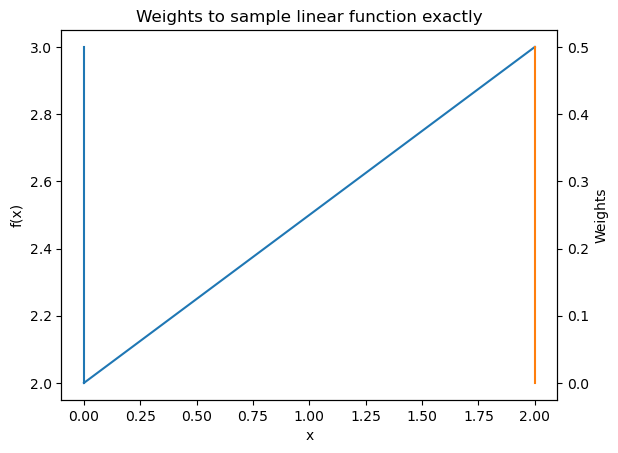

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# a straight line
def f(x):
    m = 0.5
    c = 2
    return m*x + c


N = 1
a = 0
b = 2
h = (b-a)/N

# populate arrays with x and y values of function
xvalues = np.linspace(a, b, 100)
yvalues = f(xvalues)

# get the axes object so we can define a 2nd y-axix
ax1 = plt.gca()
ax1.plot (xvalues, yvalues)


# next calculate the sampling points and store in array
xp = np.arange(a,b+h,h)
wp = np.zeros([len(xp)], float)

# initially set all weights to 1
wp.fill(1)
# change weights at endpoints
wp[0]=1/2
wp[N]=1/2
 
# create a second y-axis
ax2 = ax1.twinx()
print ("sum of weights= ", sum(wp))

# Plot the weights on second y-axis
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')
    
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax2.set_ylabel("Weights")
plt.title("Weights to sample linear function exactly")
plt.show()
#inc=4
#for x in np.arange(0, b+inc, inc): 
#    plt.plot([x,x], [0,f(x)], 'k')

Notice we would only need two sample points to fit this. 

And if the integrand was quadratic we only need three samples points.

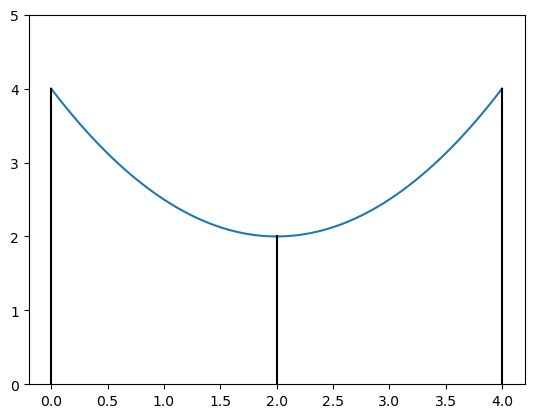

In [7]:
# a quadratic
def f(x):
    a = 0.5
    b = -2
    c = 4
    return a*x**2 + b*x +c

a=0
b=4
xvalues = np.linspace(0, b, 100)
yvalues = f(xvalues)

plt.plot (xvalues, yvalues)
plt.ylim(0,5)
inc=2
for x in np.arange(0, b+inc, inc): 
    plt.plot([x,x], [0,f(x)], 'k')

We would only need three sampling points to fit a quadratic.

In general we can fit a polynomial of order $N-1$  with $N$ sampling points. 

Until now we've assumed that our sampling points are evenly spaced. But what if we allow them to be spaced unevenly? For $N$ sampling points, we now have another $N$ degrees of freedom, for a total of 2N degrees of freedom. This may mean that we could fit polynomials up to power $2N-1$ with $N$ sampling points, not just polynomials of power $N-1$ that we can with evenly-spaced sampling points. If so, we can get a lot more "bang for our buck" with each sampling point, producing a faster more accurate method to estimate integrals.

This is the gist of the integration method called **Gaussian quadrature** (note "quadrature" refers to any numerical integration method). We not only choose how many sampling points to use, but *how* they are spaced. This produces one of the most accurate integration methods available.

Let's do a quick demonstration before we derive the method.

Let's go back to the integral:

$$
\int_a^b (x^4 -2^x+1)dx
$$

and estimate with the Gaussian quadrature method. 

Note to run this you need to download the *gaussxw* module. See directions below. 

In [12]:
# estimate integral using Gaussian quadrature

# Note: You need to download this module from Canvas
from gaussxw import gaussxw

#define our function
def f(x):
    return x**4 - 2*x + 1

# number of sampling points
N = int(input("How many sampling points do you wish to use?: ")) 

# integration interval
a = 0
b = 2

# Calculate the Gaussian quadrature sample points and weights, then map the points and weights
# to the required integration domain
x,w = gaussxw(N)
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# initialize the sum
s = 0.0

# Estimate integral using Gaussian Quadrature 
for k in range(N):
    s += wp[k]*f(xp[k])

print(f"Using N = {N} the estimate of the integral is {s:0.3f}.")
print(f"The approximation error is {abs(4.4-s):.2e}.")


How many sampling points do you wish to use?:  3


Using N = 3 the estimate of the integral is 4.400.
The approximation error is 7.11e-15.


A few things to note:

1. The approximation error is nearly at the limit of the rounding error.
2. We only need  3 sampling points (or 2 slices) to estimate the integral to near the limit of numerical precision. Seems like magic!
3. Also note the summation. You see it is just the sum of the integrand evaluated at the sampling points multiplied by a set of weights. In other words, this has the same form as our trapezoidal rule, Simpson's rule, and higher order rules.


Just to remind you how poorly the trapezoid rule does using three sampling points (or 2 slices) let's rerun it:

In [13]:
# use trapezoidal rule to integrate

# define the function in the integrand
def f(x):
    return x**4-2*x+1

# set the limits of integration
a=0
b=2

# number of sampling points
N = int(input("How many slices do you wish to use?: ")) 

# calculate width of each slice
h = (b-a)/N

Isum=0
# perform the summation from k=1, N-1
for k in range(1, int(N)):
    Isum += f(a+k*h)

# Multiply through by h and add the end terms
I = h*(0.5*(f(a) + f(b)) +Isum)
print(f"Using the trapezoid rule and N={N}, the estimate of the integral is {I}")
print(f"The relative error is {abs(100*(4.4-I)/4.4):0.1f}%.") 

How many slices do you wish to use?:  2


Using the trapezoid rule and N=2, the estimate of the integral is 7.0
The relative error is 59.1%.


As expected the trapezoidal rule performs poorly producing an estimate with an error of nearly 60%.

So how is the GQ able to produce such accurate results with so few sampling points?

Let's take a look at the sampling points used in GQ. 

*xp* is the array that holds the sampling points in the program above. Let's plot these:

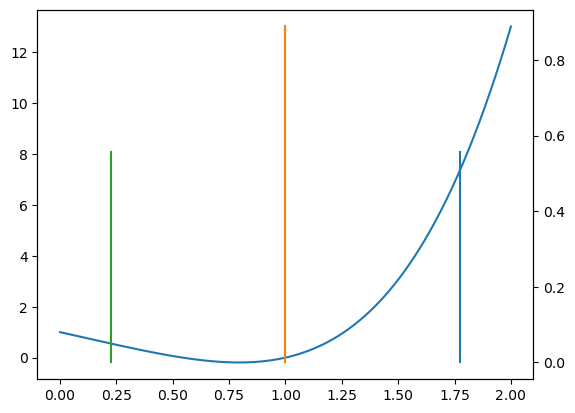

In [14]:
# Plot sampling points and weights used in Gaussian Quadrature

npoints = 1000
xpoints = np.linspace(a, b, npoints)
ypoints = f(xpoints)

# grab the current axes
ax1 = plt.gca()
# create a new axes that shares x=axis with ax1
ax2 = ax1.twinx()

# plot the function on ax1
ax1.plot (xpoints, ypoints)

# Draw a line at each sampling point, extending up to the weight of the sampling point
for i in range(len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')

The curved line is the function we're integrating from a=0 to b=2. The vertical lines are located at the sampling points $x_p$. 

Notice there are three lines corresponding to our three sampling points. 

Also note that the sampling points are not evenly spaced. The outer points are spaced about 0.25 away from the end points $a$ and $b$, while the middle point is spaced about 0.75 from these. 

It is the uneven spacing of the sampling points that makes all the difference. The spacing is optimized to produce the most accurate approximation. That's where the magic lies.  

The heights of the vertical lines are the weights $w_k$ that multiply the value of the integrand at each sampling point. We see the middle sampling point has a higher weight than the others. 

With $N$ sampling points the method can give exact answers up to polynomials of order $2N-1$, which for $N=3$ is a 5th-order polynomial. The function we integrated, $x^4-2x^2 + 1$ is only 4th-order, so we would expect it to produce a nearly exact solution, which it did.

Let's test this out. I'm copying my code from above here so it is easier to work with.

First let's try running it with only 2 sampling points (N=2). According to our rule we can estimate an exact solution up to 2N-1, so a 3rd-order polynomial. Since we have a 4th-order polynomial, we shouldn't get an exact solution.

Change to N=2. 

In [ ]:
# estimate integral using Gaussian quadrature
from gaussxw import gaussxw

#define our function
def f(x):
    return x**4 - 2*x + 1

#define a 5th-order function
#def f(x):
#    return x**5 + 1
#true5 = 64/6 +2

N = 2

a = 0
b = 2

# Calculate the sample points and weights, then map them
# to the required integration domain
x,w = gaussxw(N)

# remap the sampling points and weights to new integration interval
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# initialize the sum
s = 0.0
# Perform the integration (eq 5.52)
for k in range(N):
    s += wp[k]*f(xp[k])

print(f"The estimate of the integral is {s:0.2f} using N={N}.")
print(f"The approximation error is {100*abs((4.4-s)/4.4):.2f}%.")
#print("The approximation error is {:.2e}.".format(abs(true5-s)))

The estimate of the integral is 4.22 using N=2.
The approximation error is 4.04%.


Sure enough we get a large error of 4%.

Let's try something else. Supposedly, for N=3 sampling points we can get an exact solution for a 5th-order polynomial. We will replace the integrand above with a 5th-order polynomial and retry.

In [16]:
# estimate integral using Gaussian quadrature
from gaussxw import gaussxw

#define our function
#def f(x):
#    return x**4 - 2*x + 1

#define a 5th-order function
def f(x):
    return x**5 + 1


# number of sampling points
N = 3

# integration interval
a = 0
b = 2

# true value of integral
true5 = 64/6 +2

# Calculate the sample points and weights, then map them
# to the required integration domain
x,w = gaussxw(N)

# remap the sampling points and weights to new integration interval
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w

# initialize the sum
s = 0.0

# Perform the Gaussian Quadrature
for k in range(N):
    s += wp[k]*f(xp[k])

print(f"The estimate of the integral is {s:0.2f} using N={N}.")
#print(f"The approximation error is {100*abs((4.4-s)/4.4):.2f}%.")
print(f"The approximation error is {100*abs((true5-s)/true5):.2e}%.")

The estimate of the integral is 12.67 using N=3.
The approximation error is 1.54e-13%.


Pretty good, the approximation error is near the rounding error.

Let's also see how the weights and the spacing of the sampling points change as we change the number of sampling points. 

In the program below we can experiment with the number of sampling points $N$, to see how the weights and locations of the sampling points change.

Play around and change the integration limits $a$ and $b$ as well.

How many sampling points?:  25


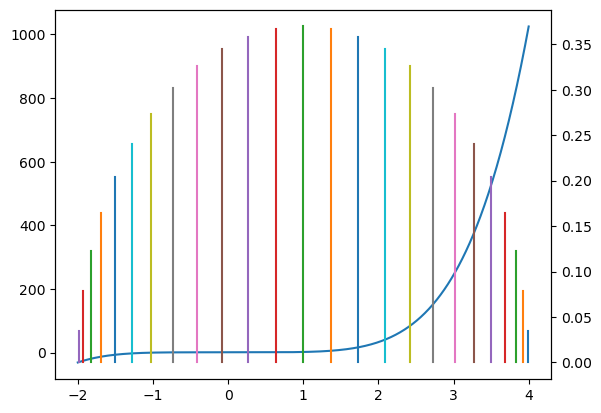

In [17]:
# Plot sampling points and weights

#def f(x):
#    return x**4 - 2*x + 1

#define a 5th-order function
def f(x):
    return x**5 + 1

    
# this first part plots the integrand
a = -2
b = 4

npoints = 1000
xpoints = np.linspace(a, b, npoints)
ypoints = f(xpoints)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot (xpoints, ypoints)

N = int(input("How many sampling points?: "))

# Calculate the sample points and weights, then map them
# to the required integration domain
x,w = gaussxw(N)
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w


# Plot the weights on second y-axis
# Resize the weights for visualization
#wp *= max(ypoints)
for i in range(0,len(xp)):
    ax2.plot ([xp[i],xp[i]], [0,wp[i]], '-')

Notice that even as we increase the number of sampling points, the basic pattern of weights and spacing remains the same. The points are spaced closer together near the ends of the interval and farther apart in the middle. The weight is always largest in the middle of the interval and lowest at the ends.

The pattern stays the same even as we change the integration interval, it is only scaled so it spans the new interval.

If we were to change the integrand (i.e., the function we are integrating), we would also find the weights and spacings remain constant. This means that for a given $N$ sampling points, we only need to calculate the weights and sampling points once. We can then rescale them to a new integration interval if we need to. 

So let's go over the basic algorithm we use for Gaussian quadrature:
1. Choose the number of sampling points N.
2. Find the sampling points $x_k$, and the weights $w_k$ for a standard integration interval, $a=-1$, $b=1$.
3. Rescale the sampling points and weights to the correct integration interval.
4. Calculate the integral using:

$$
I\sim\sum_{k=1}^{N}w_kf(x_k)
$$

The most difficult step is step 2, calculating the location of the sampling points and the weights. These are difficult to calculate. However, since the sampling points and weights are independent of the specific integrand you're integrating, there are tables of these. For example here [Table of weights and sampling points](https://pomax.github.io/bezierinfo/legendre-gauss.html).

However the author of our textbook has also provided a Python function, *gaussxw*,  we can use to calculate the locations and weights of the sampling points, which is the preferred option. It's found in the **gaussxw** module you can download from the author's website:

[gaussxw.py](http://www-personal.umich.edu/~mejn/cp/programs/gaussxw.py)

The file is also on our Canvas site. Put it in the same directory as your python script or notebook. 

The module contains two functions, *gaussxw* and *gaussxwab*. They're both easy to use. The syntax of the first function is:

```python
gaussxw(N)
gaussxwab(N,a,b)
```

The only argument you have to pass to *gaussxw* is the number of sampling points $N$ you want. The function returns two 1D arrays each of size $N$, one holding the sampling point locations $x_k$, and the other the weights $w_k$.

You can use it like:

```python
xp, wp = gaussxw(N)
```

The function calculates $x$ and $w$ using a standard integration interval from a=-1 to b=1. 

I have already shown you code that uses Gaussian quadrature to estimate integrals. Let's take another look at that:

In [18]:
# quick demo of using function gaussxw to find the weights and locations
# of sampling points for Gaussian quadrature method

from gaussxw import gaussxw

# define the number of sampling points
N = 5

# call function gaussxw with N. gaussxw returns 2 1D arrays
# x_k will hold the locations of the sampling points
# w_k holds the weights
x_k, w_k = gaussxw(N)

print(f"Sampling points: {x_k}")
print(f"Weights: {w_k}")

Sampling points: [ 9.06179846e-01  5.38469310e-01 -8.97547387e-17 -5.38469310e-01
 -9.06179846e-01]
Weights: [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]


Unless (-1,1) is your integration interval, you will need to map both the $x_k$ and $w_k$ to your correct interval (a,b). 

This is easy to do using:

$
x'_k = \frac{1}{2}(b-a)x_k + \frac{1}{2}(b+a)
$

$
w'_k =\frac{1}{2}(b-a)w_k
$

where the unprimed $x_k$ and $w_k$ are the values calculated over the standard interval (-1,1) and the primed values are those mapped to the specified integration interval (a,b)

In [ ]:
# quick demo of using function gaussxw to find the weights and locations
# of sampling points for Gaussian quadrature method

from gaussxw import gaussxw

# define the number of sampling points
N = 5

# call function gaussxw with N. gaussxw returns 2 1D arrays
# x_k will hold the locations of the sampling points
# w_k holds the weights
x_k, w_k = gaussxw(N)

# map sampling locations and weights to correct integration interval
a = -2
b = 5

x_kp  = 0.5*(b-a)*x_k + 0.5*(b+a)
w_kp = 0.5*(b-a)*w_k

print(f"Sampling points: {x_k}")
print(f"Weights: {w_k}")

In fact, this mapping is done for you if you use the second function *gaussxwab(N,a,b)*. In addition to passing the number of sampling points $N$, you also pass your integration interval (a,b). The function returns the mapped values $x_k'$ and $w_k'$. 


In [ ]:
# quick demo of using function gaussxw to find the weights and locations
# of sampling points for Gaussian quadrature method

from gaussxw import gaussxwab

# define the number of sampling points
N = 5

# define the integration interval
a = -2
b = 5
# call function gaussxwab with N,a,b. 
# Now the correct sampling locations and weights are returned.
# No need to map them into the correct interval.
x_k, w_k = gaussxwab(N,a,b)

print(f"Sampling points: {x_k}")
print(f"Weights: {w_k}")

**Overview of the Gaussian quadrature derivation**

The full details of how the Gaussian quadrature is derived are in the textbook. Here I provide a general schematic.

1. We want to generate an integration rule of the type above for a non-uniform set of $N$ sampling points $x_k$.

$$
\int_a^b f(x)dx \sim \sum_{k=1}^{N}w_kf(x_k)
$$

2. We sample the function $f(x)$ at the sampling points $x_k$. So we get a set of  $N$ points $f(x_k$).

3. We can fit $N$ points exactly with an $N-1$ polynomial, so that's what we do. Note this will be an exact fit to the $N$ points, but not necessarily an exact fit to the function $f(x)$. This is done using *interpolating polynomials*, $\phi_k(x)$, such that the fit is:

$$
\Phi(x) = \sum_{k=1}^{N}f(x_k)\phi_k(x)
$$


4. We then integrate this polynomial over our integration interval (a,b). This gives us an approximation to the true integral. The result of this step is:

$$
\int_a^b f(x)dx \sim \sum_{k=1}^{N}f(x_k)\underbrace{\int_a^b\phi_k(x)dx}_{w_k}
$$


Comparing this to the equation above, we see the weights $w_k$ in the integration rule above are given by:

$$
w_k = \int_a^b \phi_k(x) dx
$$

These integrals can't be solved analytically, so numerical methods must be used. Fortunately, once we calculate them for $N$ sampling points, we don't need to calculate them again. 

In order for the sampling points to be optimized they must correspond to the roots of Legendre polynomials. In particular, the locations of $N$ sampling points are the roots of the $Nth$ Legendre polynomial $P_N(x)$. 


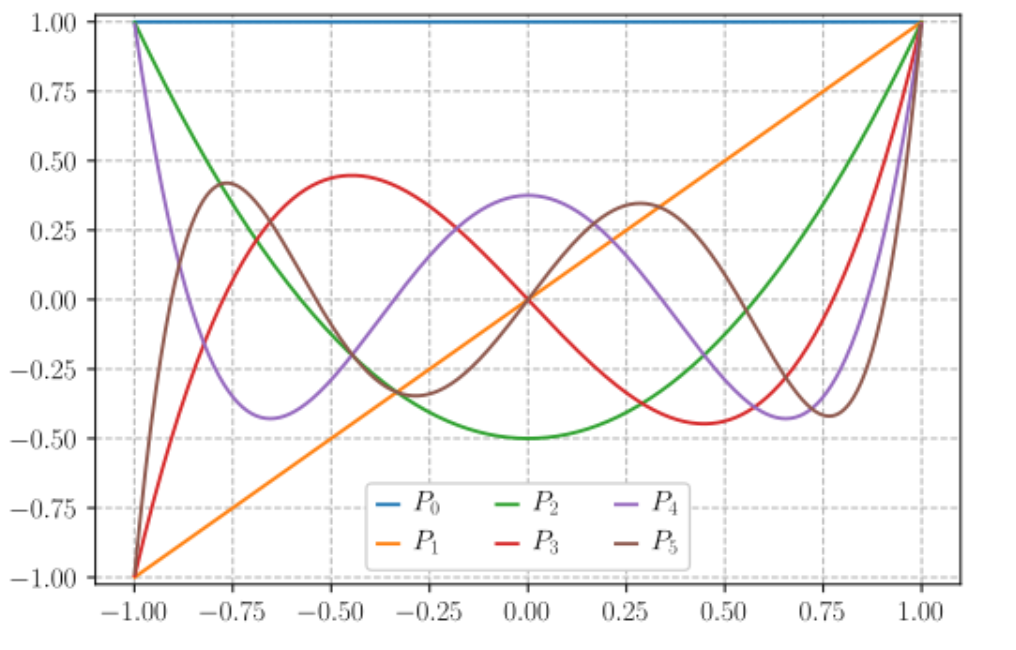

Image source: Wikipedia.

We can plot a few Legendre polynomials to demonstrate. The script below plots the Nth Legendre polynomial so we can see where the roots occur. Note that an Nth order Legendre polynomial has N roots. 

We can compare the locations of the roots with the locations of the sampling points in Gaussian quadrature using the *gaussxw* function which returns the N weights and sampling locations. Feel free to explore by changing N in the script. 



What Legendre polynomial (N) do wish to plot?:  4


 Legrendre roots   Sampling points using gaussxw 
     -0.861                   -0.861             
     -0.340                   -0.340             
      0.340                    0.340             
      0.861                    0.861             


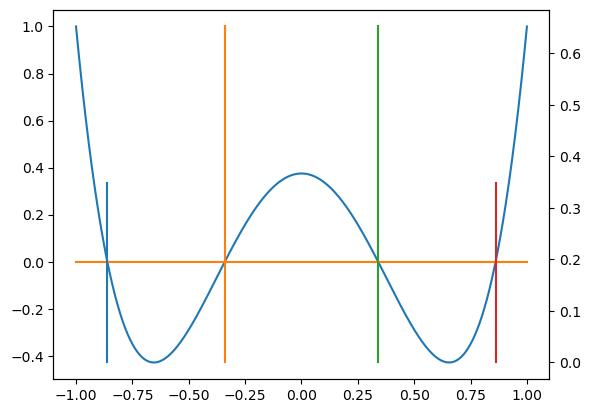

In [20]:
# plot Legendre polynomials
from scipy.special import legendre
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxw, gaussxwab

# the legendre polynomial outputs a poly2D object
N = int(input("What Legendre polynomial (N) do wish to plot?: ")) 
p = legendre(N)

# evaluate at xpoints
xpoints = np.linspace(-1,1,1000)
ypoints = p(xpoints)


# compare to the sampling locations returned by gaussxw
x,w = gaussxw(N)

x = list(x)
x.sort()
plist = list(p.r)
plist.sort()
print(f"{'Legrendre roots':^17} {'Sampling points using gaussxw':^31}")
for i in range(N):
    print(f"{plist[i]:^17.3f} {x[i]:^31.3f}")

# Overlay the weights  w_k
# create second y-axis
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot (xpoints, ypoints)
ax1.plot([-1,1], [0,0])

# Plot the weights on second y-axis
for i in range(N):
    ax2.plot ([x[i],x[i]], [0,w[i]], '-')

 So this is the Gaussian quadrature approximation to the true integral. The sampling points $x_k$ and weights $w_k$ are calculated for us by the function *gaussxw* over the interval (-1,1). All we need to do is map these back into our integration interval as we did above. 

### Practice Exercise - Gaussian Quadrature

Use Gaussian quadrature to evaluate the following integral with $N=50$ sample points. 

Debye's theory of solids gives the heat capacity of a solid at
temperature $T$ to be

\begin{equation*}
C_V(T) = 9V\rho k_B \biggl( {T\over\theta_D} \biggr)^3 \int_0^{\theta_D/T}
      {x^4 e^x\over(e^x-1)^2}\>d x,
\end{equation*}

where $V$ is the volume of the solid, $\rho$ is the number density of
atoms, $k_B$ is Boltzmann's constant, and $\theta_D$ is the so-called
_Debye temperature_, a property of solids that depends on their
density and speed of sound.

Calculate $C_V$ at $T=300$K for a
  a sample of solid aluminum with volume $V=0.001 \mathrm{m}^{-3}$, a number density of
  $\rho=6.022\times10^{28}\,\mathrm{m}^{-3}$ and a Debye temperature of
  $\theta_D=428\,$K.  
  

  
To save some time, the prefactor in front of the integral is $2.577e3$.

You should find $C_V(T=300K) = $ 2257.80 J/K. 

In [ ]:
### Practice Exercise - Gaussian Quadrature
# Debye's heat capacity



Note: Unlike the trapezoidal rule and Simpson's rule there are no general equations we can use to estimate the error on the integral calculated using Gaussian quadrature. 

In general this isn't a problem because the Gaussian quadrature method is so accurate that we don't need that many sampling points to get a very accurate estimate of the integral (typically $N<100$).

Also, the accuracy of the estimate increases rapidly with $N$. Generally the approximation error improves by a factor of $~1/N^2$ as we increase $N$ by $1$. So if we increase $N$ from $5$ to $6$, the approximation error decreases by a factor on the order of $25$, or if we increase $N$ from 10 to 11, it will decrease by a factor of 100.

Because the accuracy increases so rapidly with $N$, if we were to repeat the calculation using $2N$ sampling points (call this estimate $I_2$), $I_2$ would be so much more accurate than $I_1$, we can treat $I_2$ as being the true value of $I$, so the approximation error on $I_1$ could be estimated as $I_2-I_1$.

